In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('spam.csv', encoding='latin-1')

In [3]:
df.sample(10)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
4720,ham,"Yup. Anything lor, if u dun wan it's ok...",NaN,NaN,NaN
5157,ham,K k:) sms chat with me.,NaN,NaN,NaN
1723,ham,"Hi Jon, Pete here, Ive bin 2 Spain recently & ...",NaN,NaN,NaN
392,ham,Morning only i can ok.,NaN,NaN,NaN
1770,ham,Dont show yourself. How far. Put new pictures ...,NaN,NaN,NaN
827,ham,Hey. You got any mail?,NaN,NaN,NaN
4110,spam,URGENT! Your Mobile number has been awarded a ...,NaN,NaN,NaN
4056,ham,Noice. Text me when you're here,NaN,NaN,NaN
234,spam,Text & meet someone sexy today. U can find a d...,NaN,NaN,NaN
34,spam,Thanks for your subscription to Ringtone UK yo...,NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

DATA CLEANING
EDA
TEXT PREPROCESSING
MODEL BUILDING
EVALUATION
IMPROVEMENTS
WEBSITE
DEPLOY

DATA CLEANING

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [6]:
# drop last 3 cols
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)
df.sample(5)

,v1,v2
4940,ham,Omg you can make a wedding chapel in frontierv...
131,ham,"Dear, will call Tmorrow.pls accomodate."
2815,ham,Genius what's up. How your brother. Pls send h...
4865,ham,"Oh! Shit, I thought that was your trip! Looooo..."
2197,ham,Bring it if you got it


In [7]:
df.rename(columns={'v1' :'target' , 'v2':'text' }, inplace=True)
df.sample(5)


,target,text
4400,ham,Many times we lose our best ones bcoz we are
2080,ham,Where is it. Is there any opening for mca.
3095,ham,We walked from my moms. Right on stagwood pass...
1709,ham,U meet other fren dun wan meet me ah... Muz b ...
3002,ham,I will see in half an hour


In [8]:
from sklearn.preprocessing import LabelEncoder
encoder =LabelEncoder()

In [9]:
df['target'] = encoder.fit_transform(df['target'])
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
#missing values
df.isnull().sum()

target    0
text      0
dtype: int64

In [11]:
df.duplicated().sum()


403

In [12]:
df=df.drop_duplicates(keep='first')

In [13]:
df.duplicated().sum()

0

In [14]:
df.shape

(5169, 2)

Exploratory Data Analysis 


In [15]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [16]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

In [17]:
import matplotlib.pyplot as plt

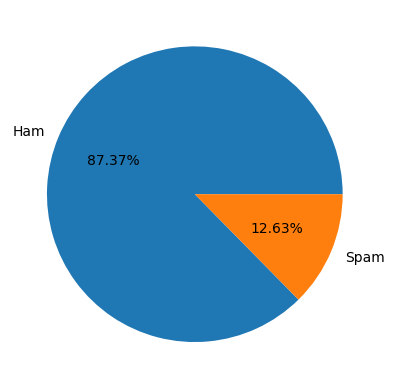

In [18]:

plt.pie(df['target'].value_counts(), labels=['Ham','Spam'], autopct='%0.2f%%')
plt.show()


In [20]:
#Data is imbalanced 
import nltk

In [21]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True

In [22]:
df['num_characters'] =df['text'].apply(len)

In [26]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [28]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [29]:
df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

0       24
1        8
2       37
3       13
4       15
        ..
5567    35
5568     9
5569    15
5570    27
5571     7
Name: text, Length: 5169, dtype: int64